# Walmart : prédire les ventes hebdomadaires

## Contexte
Le service marketing de Walmart veut estimer les ventes hebdomadaires de ses magasins à partir de quelques indicateurs : la température, le prix du carburant, le CPI (indice des prix à la consommation, un indicateur d'inflation), le taux de chômage et la présence d'un jour férié.

Objectif : construire un modèle de régression qui prédit `Weekly_Sales`, et voir quelles variables influencent le plus les ventes.

## Plan
1. EDA et préparation des données
2. Modèle de base : régression linéaire
3. Régularisation : Ridge et Lasso
4. Résultat

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV


# Part 1 : EDA and preprocessing

In [34]:
df = pd.read_csv("Walmart_Store_sales.csv")
df.shape

(150, 8)

In [35]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,6.0,18-02-2011,1572117.54,NaN,59.61,3.045,214.777523,6.858
1,13.0,25-03-2011,1807545.43,0.0,42.38,3.435,128.616064,7.470
2,17.0,27-07-2012,NaN,0.0,NaN,NaN,130.719581,5.936
3,11.0,NaN,1244390.03,0.0,84.57,NaN,214.556497,7.346
4,6.0,28-05-2010,1644470.66,0.0,78.89,2.759,212.412888,7.092


In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         150 non-null    float64
 1   Date          132 non-null    str    
 2   Weekly_Sales  136 non-null    float64
 3   Holiday_Flag  138 non-null    float64
 4   Temperature   132 non-null    float64
 5   Fuel_Price    136 non-null    float64
 6   CPI           138 non-null    float64
 7   Unemployment  135 non-null    float64
dtypes: float64(7), str(1)
memory usage: 9.5 KB


In [37]:
df.isna().sum()

Store            0
Date            18
Weekly_Sales    14
Holiday_Flag    12
Temperature     18
Fuel_Price      14
CPI             12
Unemployment    15
dtype: int64

Le jeu de données contient 150 lignes et presque toutes les colonnes ont des valeurs manquantes. La cible `Weekly_Sales` en a 14 : on supprime ces lignes, car on ne remplace jamais la valeur à prédire. Les valeurs manquantes des variables explicatives seront remplacées plus tard, dans le pipeline (médiane pour les variables numériques, valeur la plus fréquente pour les variables catégorielles).

In [38]:
df = df.dropna(subset=['Weekly_Sales'])

In [39]:
df.info()

<class 'pandas.DataFrame'>
Index: 136 entries, 0 to 149
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         136 non-null    float64
 1   Date          118 non-null    str    
 2   Weekly_Sales  136 non-null    float64
 3   Holiday_Flag  125 non-null    float64
 4   Temperature   121 non-null    float64
 5   Fuel_Price    124 non-null    float64
 6   CPI           125 non-null    float64
 7   Unemployment  122 non-null    float64
dtypes: float64(7), str(1)
memory usage: 9.6 KB


## Exploration des données

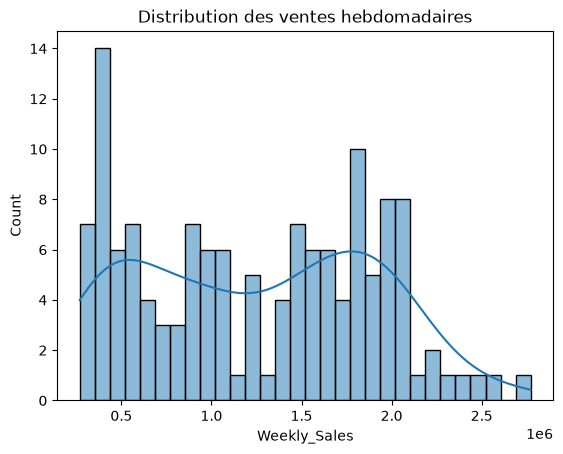

In [40]:
sns.histplot(df['Weekly_Sales'], bins=30, kde=True)
plt.title("Distribution des ventes hebdomadaires")
plt.show()

La distribution des ventes n'est pas une courbe en cloche : on voit plusieurs bosses. Ça s'explique par les magasins, qui ont des niveaux de ventes très différents (voir le graphique suivant).

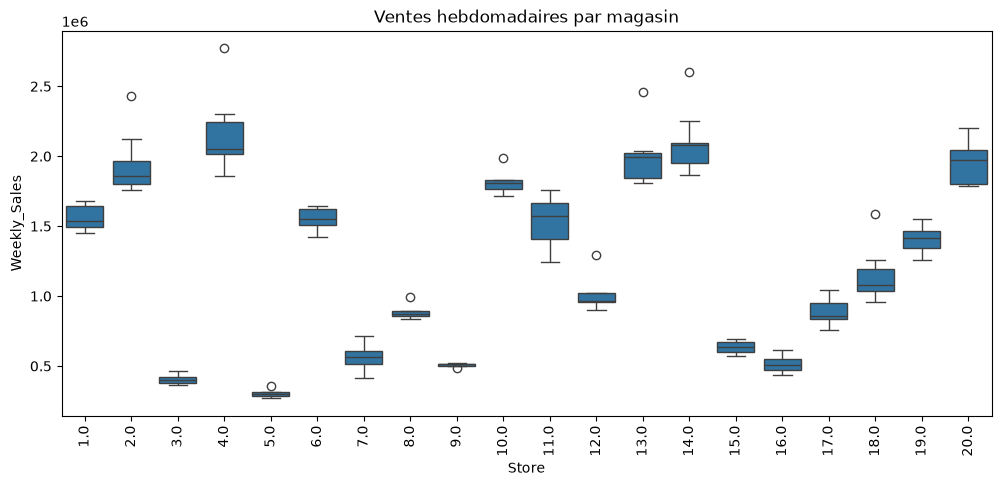

In [41]:
plt.figure(figsize=(12,5))
sns.boxplot(x='Store', y='Weekly_Sales', data=df)
plt.xticks(rotation=90)
plt.title("Ventes hebdomadaires par magasin")
plt.show()

Les ventes dépendent fortement du magasin. La moyenne des ventes varie de 300k€ (magasin 5) à plus de 2 millions (magasin 4). La variable "store" sera donc importante pour le modèle.

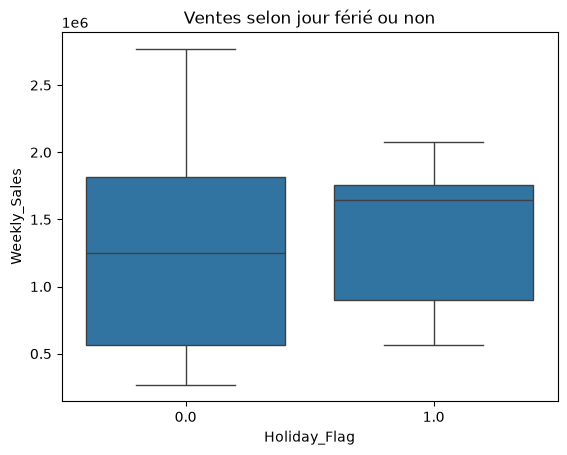

In [42]:
sns.boxplot(x='Holiday_Flag', y='Weekly_Sales', data=df)
plt.title("Ventes selon jour férié ou non")
plt.show()

In [43]:
df['Holiday_Flag'].value_counts(dropna=False)

Holiday_Flag
0.0    116
NaN     11
1.0      9
Name: count, dtype: int64

Les semaines de jour férié ont des ventes moyennes un peu plus élevées, mais la différence ne paraît pas significative (d'autant plus que l'on a très peu de semaines avec un jour férié)

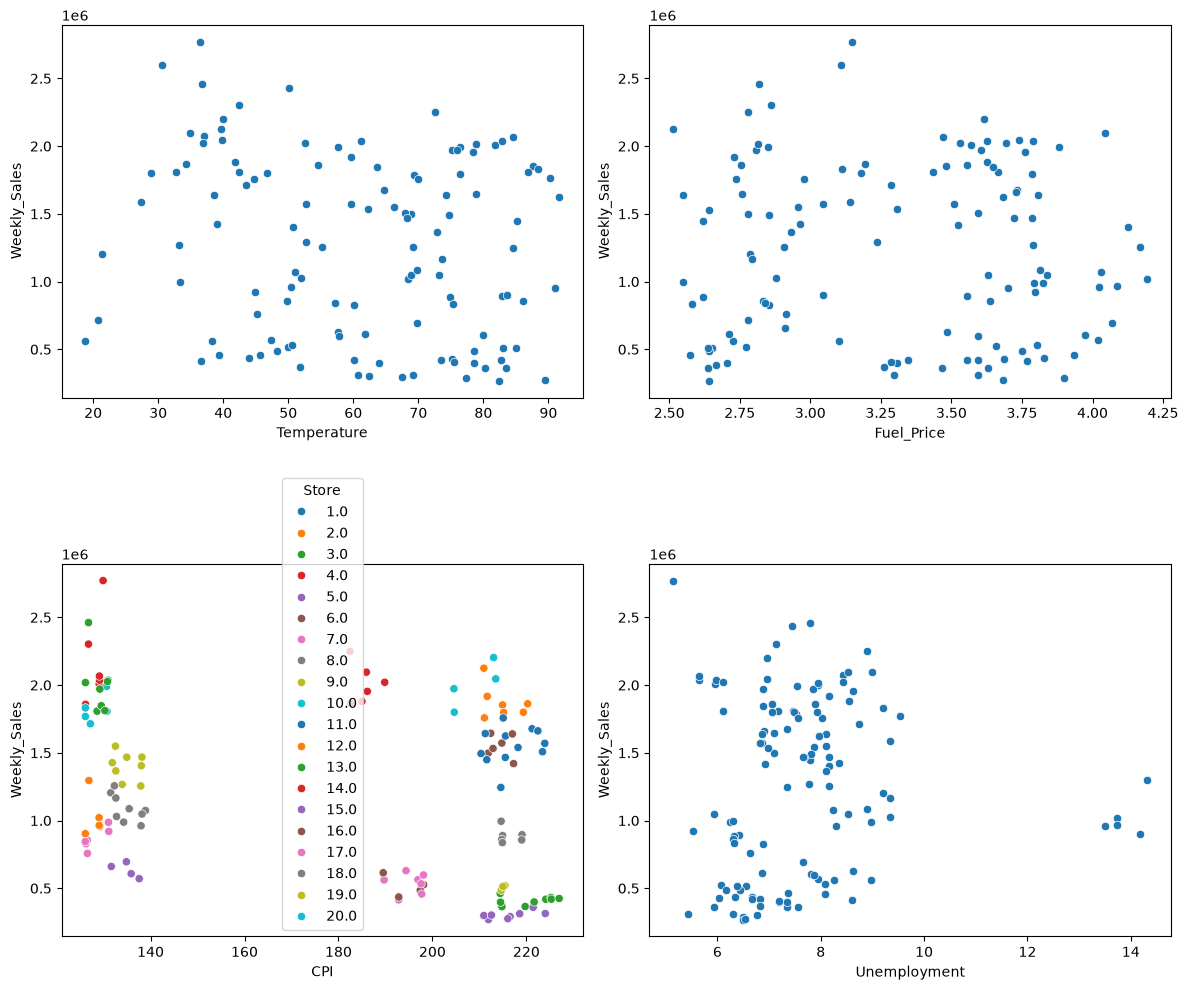

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.scatterplot(x='Temperature', y='Weekly_Sales', data=df, ax=axes[0,0])
sns.scatterplot(x='Fuel_Price', y='Weekly_Sales', data=df, ax=axes[0,1])
#sns.scatterplot(x='CPI', y='Weekly_Sales', data=df, ax=axes[1,0])
sns.scatterplot(x='CPI', y='Weekly_Sales', data=df, hue='Store', palette='tab10', ax=axes[1,0])
sns.scatterplot(x='Unemployment', y='Weekly_Sales', data=df, ax=axes[1,1])
plt.tight_layout()
plt.show()

Sur le graphique ventes / CPI (indice des prix à la consommation), on voit des groupes de points séparés. En colorant par magasin, on constate que chaque magasin a un CPI à peu près constant : le CPI varie surtout d'un magasin à l'autre, très peu dans le temps. Il est donc lié à la variable "store".

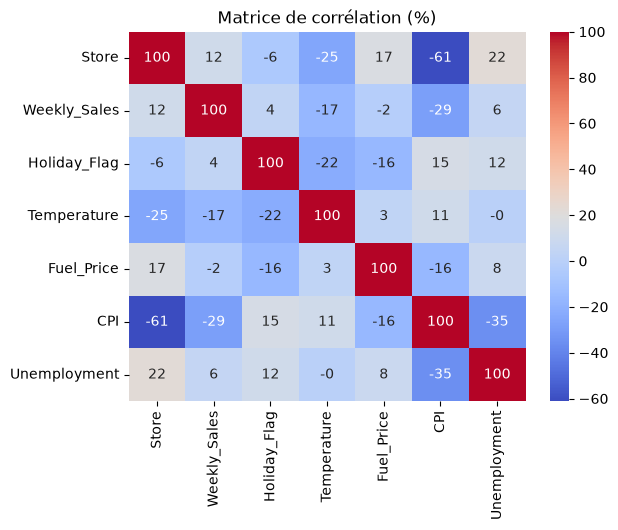

In [45]:
sns.heatmap(df.corr(numeric_only=True)*100, annot=True, fmt='.0f', cmap='coolwarm')
plt.title("Matrice de corrélation (%)")
plt.show()

La matrice de corrélation montre des liens relativement faibles entre les variables économiques et les ventes (-0,31 pour le CPI -0.16 pour la température et 19 pour le chomage). Les variables économiques seules expliquent donc peu les ventes. On retrouve cependant le lien fort entre CPI et store vu précédemment.

## Préparation des données avec pandas

In [46]:
#create features from the Date column
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek

df = df.drop('Date', axis=1)
df.head()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Day,DayOfWeek
0,6.0,1572117.54,NaN,59.61,3.045,214.777523,6.858,2011.0,2.0,18.0,4.0
1,13.0,1807545.43,0.0,42.38,3.435,128.616064,7.470,2011.0,3.0,25.0,4.0
3,11.0,1244390.03,0.0,84.57,NaN,214.556497,7.346,NaN,NaN,NaN,NaN
4,6.0,1644470.66,0.0,78.89,2.759,212.412888,7.092,2010.0,5.0,28.0,4.0
5,4.0,1857533.70,0.0,NaN,2.756,126.160226,7.896,2010.0,5.0,28.0,4.0


In [47]:
df['DayOfWeek'].value_counts(dropna=False)

DayOfWeek
4.0    118
NaN     18
Name: count, dtype: int64

La colonne date ne peut pas être utilisée telle quelle par un modèle. On en extrait l'année, le mois, le jour et le jour de la semaine. On remarque que toutes les dates sont des vendredis (DayOfWeek = 4), cette colonne n'apportera aucune information au modèle.

In [48]:
# Drop outliers on Temperature, Fuel_Price, CPI, Unemployment
outlier_cols = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

for col in outlier_cols:
    mean = df[col].mean()
    std = df[col].std()
    to_keep = (
            (df[col] >= mean - 3 * std) & (df[col] <= mean + 3 * std)
           ) | (df[col].isnull())
    df = df.loc[to_keep, :]

df.shape


(131, 11)

On retire les valeurs extrêmes de Temprature, Fuel_Price, CPI et Unemployment : une valeur est écartée si elle sort de l'intervalle moyenne +- 3 écarts-types. On garde les lignes avec une valeur manquante, qui seront traitées ultérieurement. Il reste 131 lignes.

In [49]:
#separate target
target = 'Weekly_Sales'

Y = df[target]
X = df.drop(target, axis=1)

# Part 2 : baseline model (linear regression)

On sépare les données en un jeu d'entraînement (80 %) et un jeu de test (20 %) avant les transformations, pour éviter que des informations du test ne fuient dans l'entraînement (data leakage).

In [50]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)
print('train_shape', X_train.shape)
print('test_shape',X_test.shape)

train_shape (104, 10)
test_shape (27, 10)


Le pipeline de préparation :
- variables numériques : valeurs manquantes remplacées par la médiane, puis normalisation (StandardScaler) ;
- variables catégorielles (Store, Holiday_Flag) : valeurs manquantes remplacées par la valeur la plus fréquente, puis one-hot encoder.


In [51]:
numeric_features = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Day', 'DayOfWeek']
categorical_features = ['Store', 'Holiday_Flag']

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)


## Régression linéaire

In [52]:
model = LinearRegression()
model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](27,)","[-37954.32,-40814.74,100863.82,...,130941.35,379836.68,-47380.38]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.496e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,27
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,26
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](27,)","[14.25,11.91,10.97,..., 0.76, 0.41, 0. ]"


In [53]:
Y_train_pred = model.predict(X_train)
Y_test_pred = model.predict(X_test)

print("R2 train:", r2_score(Y_train, Y_train_pred))
print("R2 test:", r2_score(Y_test, Y_test_pred))
print()
print("MAE train:", mean_absolute_error(Y_train, Y_train_pred))
print("MAE test:", mean_absolute_error(Y_test, Y_test_pred))
print()
print("RMSE train:", np.sqrt(mean_squared_error(Y_train, Y_train_pred)))
print("RMSE test:", np.sqrt(mean_squared_error(Y_test, Y_test_pred)))


R2 train: 0.9740718051467115
R2 test: 0.936452819314395

MAE train: 79292.01022084247
MAE test: 125063.46939002944

RMSE train: 106272.08293866715
RMSE test: 155379.86177817386


In [54]:
print(Y.mean())

1257990.439312977


**Interprétation des métriques**
- R² : 0,936 sur le test. Le modèle explique environ 94 % de la variance des ventes sur des données qu'il n'a jamais vues.
- L'erreur moyenne absolue (MAE) sur le test est d'environ 125 000 \$, alors que les ventes moyennes sont d'environ 1.26 millions \$, cela revient à une erreur moyenne de l'ordre de 10%.
- L'écart entre le train et le test indique un léger surapprentissage (overfitting).

## Interprétation des coefficients

In [55]:
feature_names = preprocessor.get_feature_names_out()

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': model.coef_
})

coef_df['abs_coefficient'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values(by='abs_coefficient', ascending=False)
coef_df.head(15)


,feature,coefficient,abs_coefficient
11,cat__Store_5.0,-1.404353e+06,1.404353e+06
15,cat__Store_9.0,-1.275038e+06,1.275038e+06
9,cat__Store_3.0,-1.259269e+06,1.259269e+06
21,cat__Store_16.0,-1.101418e+06,1.101418e+06
13,cat__Store_7.0,-8.817075e+05,8.817075e+05
14,cat__Store_8.0,-7.537089e+05,7.537089e+05
16,cat__Store_10.0,7.306707e+05,7.306707e+05
19,cat__Store_14.0,7.269425e+05,7.269425e+05
10,cat__Store_4.0,6.613985e+05,6.613985e+05
22,cat__Store_17.0,-6.270616e+05,6.270616e+05


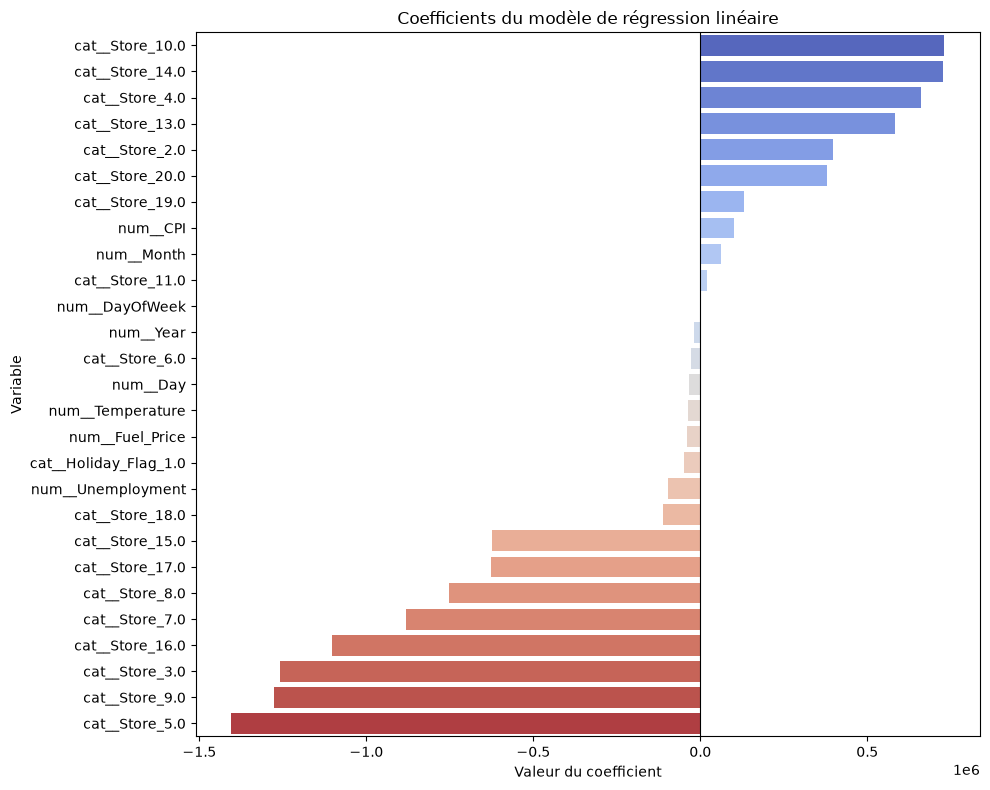

In [56]:
coef_plot = coef_df.sort_values(by='coefficient', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=coef_plot, x='coefficient', y='feature', hue='feature', palette='coolwarm', legend=False)
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Coefficients du modèle de régression linéaire")
plt.xlabel("Valeur du coefficient")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

Les coefficients les plus grands (en valeur absolue) sont tous des magasins (store). C'est donc la variable magasin qui influe le plus sur les ventes hebdomadaires. Cela confirme ce que lon avait vu dans l'EDA. 

Les variables économiques ont des coefficients beaucoup plus petits. Sans surprise, la variable DayOfWeek n'a pas d'impact (elle est constante). L'effet du jour férié est faible et négatif une fois le magasin pris en compte, alors qu'il paraissait positif sur les moyennes : avec très peu de semaines de jour férié, on ne peut pas conclure.

En conclusion, la variable qui fait le plus varier les ventes, est la variable "magasin".
Si l'on voulait creuser un peu plus, il faudrait d'autres informations sur le magasin (taille, emplacement, horaires...)

# Part 3 : regularization Lasso / Ridge

On utilise la régularisation de Ridge puis de Lasso pour réduire le léger surapprentissage.

**Métrique R²**

In [57]:
#Ridge

ridge_model = Ridge(alpha=1.0) #penalité à 1 pour avoir une base de départ.
ridge_model.fit(X_train, Y_train)

Y_train_pred_ridge = ridge_model.predict(X_train)
Y_test_pred_ridge = ridge_model.predict(X_test)

print("R2 train (Ridge):", r2_score(Y_train, Y_train_pred_ridge))
print("R2 test (Ridge):", r2_score(Y_test, Y_test_pred_ridge))
print()
print("MAE train (Ridge):", mean_absolute_error(Y_train, Y_train_pred_ridge))
print("MAE test (Ridge):", mean_absolute_error(Y_test, Y_test_pred_ridge))
print()
print("RMSE train (Ridge):", np.sqrt(mean_squared_error(Y_train, Y_train_pred_ridge)))
print("RMSE test (Ridge):", np.sqrt(mean_squared_error(Y_test, Y_test_pred_ridge)))

R2 train (Ridge): 0.934051967530561
R2 test (Ridge): 0.9269394007833482

MAE train (Ridge): 139352.55351502585
MAE test (Ridge): 126396.96185772297

RMSE train (Ridge): 169486.05595187956
RMSE test (Ridge): 166605.06559505337


In [58]:
# Lasso

lasso_model = Lasso(alpha=1.0)
lasso_model.fit(X_train, Y_train)

Y_train_pred_lasso = lasso_model.predict(X_train)
Y_test_pred_lasso = lasso_model.predict(X_test)

print("R2 train (Lasso):", r2_score(Y_train, Y_train_pred_lasso))
print("R2 test (Lasso):", r2_score(Y_test, Y_test_pred_lasso))
print()
print("MAE train (Lasso):", mean_absolute_error(Y_train, Y_train_pred_lasso))
print("MAE test (Lasso):", mean_absolute_error(Y_test, Y_test_pred_lasso))
print()
print("RMSE train (Lasso):", np.sqrt(mean_squared_error(Y_train, Y_train_pred_lasso)))
print("RMSE test (Lasso):", np.sqrt(mean_squared_error(Y_test, Y_test_pred_lasso)))


R2 train (Lasso): 0.9740718027776665
R2 test (Lasso): 0.936475478996551

MAE train (Lasso): 79288.22391958884
MAE test (Lasso): 125049.04010269167

RMSE train (Lasso): 106272.0877936783
RMSE test (Lasso): 155352.156597813


In [59]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso'],
    'R2': [
        r2_score(Y_test, Y_test_pred),
        r2_score(Y_test, Y_test_pred_ridge),
        r2_score(Y_test, Y_test_pred_lasso)
    ],
    'MAE': [
        mean_absolute_error(Y_test, Y_test_pred),
        mean_absolute_error(Y_test, Y_test_pred_ridge),
        mean_absolute_error(Y_test, Y_test_pred_lasso)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(Y_test, Y_test_pred)),
        np.sqrt(mean_squared_error(Y_test, Y_test_pred_ridge)),
        np.sqrt(mean_squared_error(Y_test, Y_test_pred_lasso))
    ]
})

results

,Model,R2,MAE,RMSE
0,Linear Regression,0.936453,125063.469390,155379.861778
1,Ridge,0.926939,126396.961858,166605.065595
2,Lasso,0.936475,125049.040103,155352.156598


Avec alpha = 1, Lasso donne des résultats presque identiques à la régression linéaire. Ridge est moins bon : R² de 0,927 sur le test contre 0,936. Cette valeur d'alpha n'est donc pas adaptée. On cherche maintenant le meilleur alpha avec GridSearchCV (validation croisée).

In [60]:
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}

ridge_grid = GridSearchCV(Ridge(), param_grid, cv=5, scoring='r2')
ridge_grid.fit(X_train, Y_train)

print("Best alpha (Ridge):", ridge_grid.best_params_)
print("Best R2 (cross-val):", ridge_grid.best_score_)
print()

lasso_grid = GridSearchCV(Lasso(max_iter=10000), param_grid, cv=5, scoring='r2')
lasso_grid.fit(X_train, Y_train)

print("Best alpha (Lasso):", lasso_grid.best_params_)
print("Best R2 (cross-val):", lasso_grid.best_score_)

Best alpha (Ridge): {'alpha': 0.001}
Best R2 (cross-val): 0.9462492355414514

Best alpha (Lasso): {'alpha': 10}
Best R2 (cross-val): 0.9462781581355145


In [61]:
best_ridge = ridge_grid.best_estimator_
best_lasso = lasso_grid.best_estimator_

Y_test_pred_best_ridge = best_ridge.predict(X_test)
Y_test_pred_best_lasso = best_lasso.predict(X_test)

print("R2 test (best Ridge):", r2_score(Y_test, Y_test_pred_best_ridge))
print("R2 test (best Lasso):", r2_score(Y_test, Y_test_pred_best_lasso))

R2 test (best Ridge): 0.9366118652694405
R2 test (best Lasso): 0.9366788116111626


In [62]:
r2_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge (best alpha)', 'Lasso (best alpha)'],
    'Alpha': [
        None,
        best_ridge.alpha,
        best_lasso.alpha
    ],
    'R2_test': [
        r2_score(Y_test, Y_test_pred),
        r2_score(Y_test, Y_test_pred_best_ridge),
        r2_score(Y_test, Y_test_pred_best_lasso)
    ]
})

r2_results = r2_results.sort_values(by='R2_test', ascending=False)
r2_results

,Model,Alpha,R2_test
2,Lasso (best alpha),10.000,0.936679
1,Ridge (best alpha),0.001,0.936612
0,Linear Regression,NaN,0.936453


Avec le meilleur alpha, Ridge (0,001) et Lasso (10) font à peine mieux que la régression linéaire : R² test de 0,9366 et 0,9367 contre 0,9365. Le gain est négligeable. C'est cohérent avec le faible surapprentissage observé au départ.

**métrique MAE**

In [63]:
ridge_grid_mae = GridSearchCV(Ridge(), param_grid, cv=5, scoring='neg_mean_absolute_error')
ridge_grid_mae.fit(X_train, Y_train)
best_ridge_mae = ridge_grid_mae.best_estimator_

lasso_grid_mae = GridSearchCV(Lasso(max_iter=10000), param_grid, cv=5, scoring='neg_mean_absolute_error')
lasso_grid_mae.fit(X_train, Y_train)
best_lasso_mae = lasso_grid_mae.best_estimator_

mae_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge (best alpha for MAE)', 'Lasso (best alpha for MAE)'],
    'Alpha': [
        None,
        best_ridge_mae.alpha,
        best_lasso_mae.alpha
    ],
    'MAE_test': [
        mean_absolute_error(Y_test, Y_test_pred),
        mean_absolute_error(Y_test, best_ridge_mae.predict(X_test)),
        mean_absolute_error(Y_test, best_lasso_mae.predict(X_test))
    ]
})

mae_results = mae_results.sort_values(by='MAE_test', ascending=True)
mae_results

,Model,Alpha,MAE_test
2,Lasso (best alpha for MAE),100.00,123619.724133
1,Ridge (best alpha for MAE),0.01,124008.226969
0,Linear Regression,NaN,125063.469390


En régularisant sur la MAE, Lasso (alpha = 100) et Ridge donnent une MAE test d'environ 124 000 \$, contre 125 000 \$ pour la régression linéaire : une amélioration d'environ 1 %. 
Point de vigilance : Ce jeu de données est petit (27 lignes de test), avec un autre découpage train/test, le classement des modèles pourrait changer.

In [64]:
# Nombre de coefficients mis à 0 par le meilleur Lasso selon le critère MAE
n_zero = (best_lasso_mae.coef_ == 0).sum()
print(n_zero, "coefficient(s) mis à 0 sur", len(best_lasso_mae.coef_))
print("Variable(s) concernée(s) :", list(feature_names[best_lasso_mae.coef_ == 0]))

1 coefficient(s) mis à 0 sur 27
Variable(s) concernée(s) : ['num__DayOfWeek']


Lasso n'élimine qu'une variable,DayOfWeek, qui est constante. Les autres variables sont toutes conservées.

### Conclusion des modèles créés

- Les données : 150 lignes au départ, 131 après nettoyage, avec beaucoup de valeurs manquantes traitées dans un pipeline Scikit-Learn.
- Le modèle : la régression linéaire explique environ 94 % de la variance des ventes sur le jeu de test, avec une erreur moyenne d'environ 125 000 \$ par semaine (environ 10%).
- La régularisation (Ridge, Lasso) améliore très peu les résultats, car le surapprentissage de départ est faible.
- La variable la plus importante est le magasin. Les indicateurs économiques et les jours fériés pèsent beaucoup moins.
- Le meilleur modèle selon la MAE est le Lasso (alpha = 100), avec une MAE test d'environ 123 600 \$.


# Résultat

On peut donc prédire les ventes hebdomadaires d'un magasin avec une erreur moyenne d'environ 124 000 \$ par semaine, soit environ 10 % de ses ventes moyennes (1,26 million \$). 


**Limites et pistes** : le jeu de données est petit et ne décrit pas les magasins (taille, emplacement). Pour mieux prédire, on pourrait ajouter des variables sur les magasins, ou entraîner un modèle par magasin avec plus d'historique.